# Análisis de `unique_identifier` duplicados en transacciones

## 1. Import Required Libraries

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_URL = "http://new-service:8000"


## 2. Load Transactions Data

Trae todas las transacciones desde la API paginando con `skip` / `limit`.

In [2]:
def fetch_all_transactions(base_url: str, page_size: int = 1000) -> list:
    all_transactions = []
    skip = 0
    while True:
        resp = requests.get(
            f"{base_url}/transactions/",
            params={"skip": skip, "limit": page_size},
        )
        resp.raise_for_status()
        batch = resp.json().get("transactions", [])
        all_transactions.extend(batch)
        if len(batch) < page_size:
            break
        skip += page_size
    return all_transactions

transactions = fetch_all_transactions(BASE_URL)
df = pd.DataFrame(transactions)

print(f"Total de transacciones: {len(df)}")
df.head()


Total de transacciones: 335


,order,description,category_name,history,amount,transaction_type,transaction_date,currency,account_id,unique_identifier,id
0,1,Grocery Store,Entertainment,This is something that happened first.,50.00,expense,NaN,SOL,example-account-001,example__unique__identifier__1,00000000-0000-0000-0000-000000000001
1,2,Restaurant,Transportation,This is something that happened second.,30.00,expense,NaN,SOL,example-account-001,example__unique__identifier__2,00000000-0000-0000-0000-000000000002
2,3,Gas Station,Utilities,This is something that happened third.,40.00,expense,NaN,SOL,example-account-001,example__unique__identifier__3,00000000-0000-0000-0000-000000000003
3,4,Movie Theater,Utilities,This is something that happened fourth.,15.50,expense,NaN,SOL,example-account-001,example__unique__identifier__4,00000000-0000-0000-0000-000000000004
4,1,TRAN.CTAS.PROP.BM,Other,NaN,30.08,expense,2026-01-01T00:00:01,USD,191-04106234-1-10,191-04106234-1-10__2026-01-01T00:00:01,73838de9-70ed-40b0-bd46-63a28ac2424b


## 3. Explorar el Dataset

In [3]:
print(df.shape)
print(df.dtypes)
print()
print("¿Existe columna 'unique_identifier'?", "unique_identifier" in df.columns)
print()
print("Muestra de unique_identifier:")
df["unique_identifier"].head(10)


(335, 11)
order                  int64
description              str
category_name            str
history                  str
amount               float64
transaction_type         str
transaction_date         str
currency                 str
account_id               str
unique_identifier        str
id                       str
dtype: object

¿Existe columna 'unique_identifier'? True

Muestra de unique_identifier:


0            example__unique__identifier__1
1            example__unique__identifier__2
2            example__unique__identifier__3
3            example__unique__identifier__4
4    191-04106234-1-10__2026-01-01T00:00:01
5    191-04106234-1-10__2026-01-04T00:00:01
6    191-04106234-1-10__2026-01-04T00:00:02
7    191-04106234-1-10__2026-01-05T00:00:01
8    191-04106234-1-10__2026-01-05T00:00:02
9    191-04106234-1-10__2026-01-06T00:00:01
Name: unique_identifier, dtype: str

## 4. Analizar `unique_identifier` duplicados

In [4]:
total = len(df)
duplicated_mask = df["unique_identifier"].duplicated(keep=False)
n_duplicated_rows = duplicated_mask.sum()

counts = df["unique_identifier"].value_counts()
repeated_ids = counts[counts > 1]

print(f"Total filas              : {total}")
print(f"Filas con uid duplicado  : {n_duplicated_rows}  ({n_duplicated_rows/total*100:.2f}%)")
print(f"unique_identifiers únicos: {counts.shape[0]}")
print(f"unique_identifiers repet.: {len(repeated_ids)}")
print()
print("Top 20 más repetidos:")
repeated_ids.head(20)


Total filas              : 335
Filas con uid duplicado  : 2  (0.60%)
unique_identifiers únicos: 334
unique_identifiers repet.: 1

Top 20 más repetidos:


unique_identifier
191-04106234-1-10__2026-06-30T00:00:01    2
Name: count, dtype: int64

## 5. Visualizar duplicados

/tmp/ipykernel_65909/2538340188.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, ax=ax, palette="Reds_r")


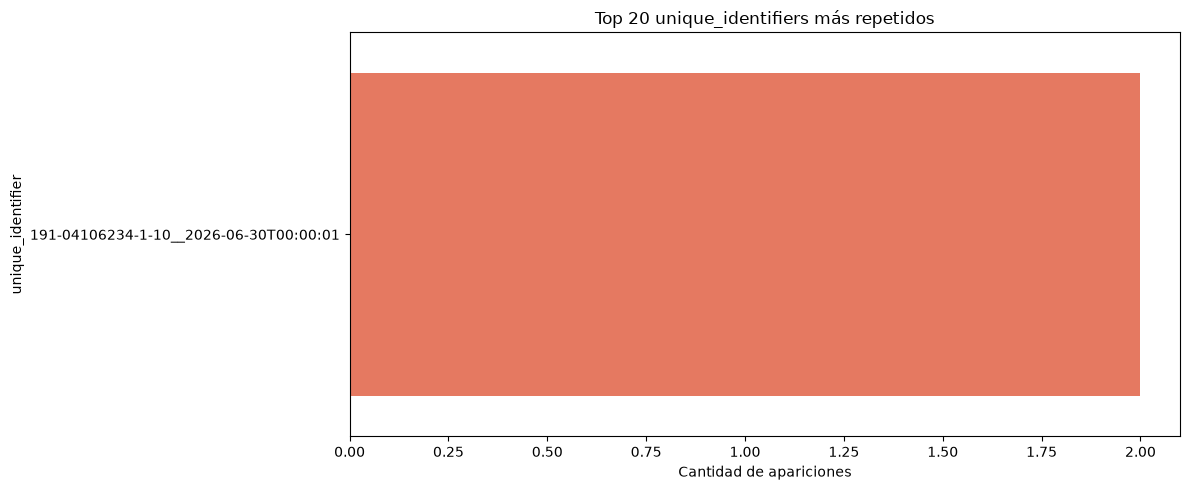

In [5]:
TOP_N = 20

if repeated_ids.empty:
    print("No hay unique_identifiers duplicados.")
else:
    top = repeated_ids.head(TOP_N)

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(x=top.values, y=top.index, ax=ax, palette="Reds_r")
    ax.set_title(f"Top {TOP_N} unique_identifiers más repetidos")
    ax.set_xlabel("Cantidad de apariciones")
    ax.set_ylabel("unique_identifier")
    plt.tight_layout()
    plt.show()


## 6. Filtrar y exportar registros duplicados

In [6]:
df_dupes = (
    df[duplicated_mask]
    .sort_values("unique_identifier")
    .reset_index(drop=True)
)

print(f"Registros con unique_identifier duplicado: {len(df_dupes)}")
df_dupes


Registros con unique_identifier duplicado: 2


,order,description,category_name,history,amount,transaction_type,transaction_date,currency,account_id,unique_identifier,id
0,43,TRAN.CTAS.PROP.BM,Other,NaN,29.55,expense,2026-06-30T00:00:01,USD,191-04106234-1-10,191-04106234-1-10__2026-06-30T00:00:01,0b025950-61e2-4587-ad59-dcf96b9adde2
1,1,TRAN.CTAS.PROP.BM,Other,NaN,29.59,expense,2026-06-30T00:00:01,USD,191-04106234-1-10,191-04106234-1-10__2026-06-30T00:00:01,feb6f635-0416-447b-bc15-c86f99ac8e2a


In [7]:
# Exportar duplicados a CSV para revisión manual
if not df_dupes.empty:
    out_path = "duplicate_unique_identifiers.csv"
    df_dupes.to_csv(out_path, index=False)
    print(f"Exportado a: {out_path}")
else:
    print("No hay duplicados que exportar.")


Exportado a: duplicate_unique_identifiers.csv
